# ***QR-Based Phishing URL Detection using ML model***
***PROJECT OVERVIEW***

1. Project Introduction
2. Import Libraries
3. Load Dataset
4. Explore Dataset
5. Data Visualization
6. Feature Engineering
7. Model Training
8. Model Evaluation
9. QR Code URL Extraction
10. Phishing Prediction
11. Conclusion

QR-Based Phishing URL Detection using ML model

->> Objective:
This project aims to detect malicious or phishing URLs hidden in QR codes, using Machine Learning algorithms and enhance security.

->> Flowchart of the System:
1. Extracts URL from QR code(s).
2. Analyzes URL characteristics.
3. Predicts whether the URL is legitimate or phishing.
4. Helps users to avoid malicious websites.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


# Import all the necessary libraries

EXPLANATION
Libraries = Use..??
1. pandas = Used for handling datasets
2. numpy = Used for numerical calculations
3. matplotlib.pyplot = Used for graphs
4. seaborn = Used for advanced visualizations
5. from sklearn.ensemble import RandomForestClassifier = Machine Learning algorithm used for classification.

In [13]:
from google.colab import drive
drive.mount('/content/drive')
# Authorizing and connecting to the google drive

Mounted at /content/drive


In [14]:
import os
folder_path = "/content/drive/MyDrive/SDC_Project"
print("Files inside SDC_Project:\n")
for file in os.listdir(folder_path):
    print(file)

# Verify the folder and printing all the files present in the folder

Files inside SDC_Project:

phishing_site_urls.csv
malicious_phish.csv
url_spam_classification.csv
phishing_url_dataset_unique.csv
qr_labels.xlsx
qr_labels.csv
qr_images.zip
qr_matrices.zip


In [15]:
import pandas as pd
qr_labels = pd.read_csv(
    "/content/drive/MyDrive/SDC_Project/qr_labels.csv"
)
print("QR Labels Loaded Successfully")
print("Shape:", qr_labels.shape)
qr_labels.head()

# Load the QR labels => 0 & 1
# 1 = Malicious
# 0 = Legitimate

QR Labels Loaded Successfully
Shape: (235787, 2)


,Unnamed: 0,label
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


In [19]:
import zipfile
zip_path = "/content/drive/MyDrive/SDC_Project/qr_images.zip"
extract_path = "/content/qr_images"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("QR Images Extracted Successfully")

# loading the QR image dataset and unzipping the file

QR Images Extracted Successfully


In [20]:
import os
image_folder = "/content/qr_images"
total_images = 0
for root, dirs, files in os.walk(image_folder):
    total_images += len(files)
print("Total QR Images:", total_images)

# Counting the total no. of QR images

Total QR Images: 261945


In [23]:
# creating the image files variable
import os
image_files = []
for root, dirs, files in os.walk("/content/qr_images"):
    for file in files:
        if file.endswith(".png"):
            image_files.append(os.path.join(root, file))

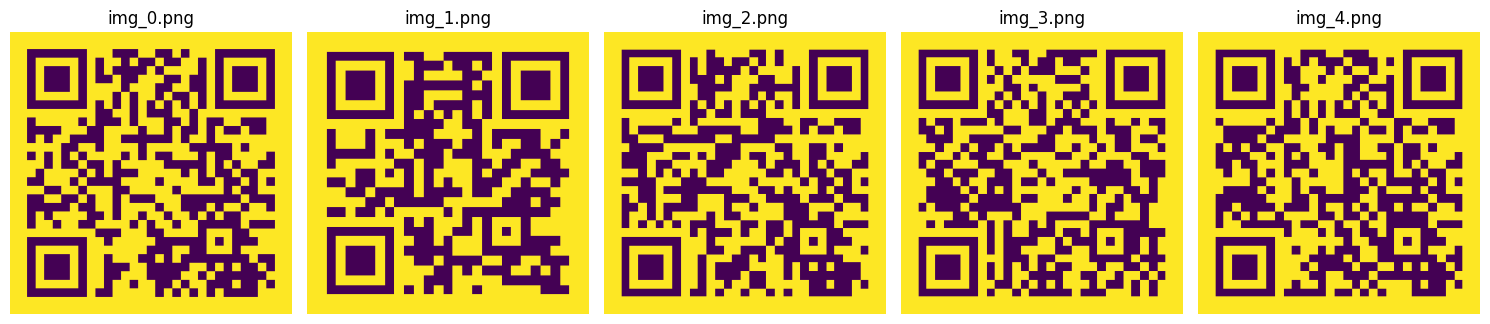

In [24]:
image_files = sorted(
    image_files,
    key=lambda x: int(
        os.path.basename(x)
        .replace("img_", "")
        .replace(".png", "")
    )
)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(15,5))

for i, img_path in enumerate(image_files[:5]):

    img = mpimg.imread(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

# Sorting the QR code images
# Displaying the first 5 QR Code images.

In [25]:
url_df = pd.read_csv(
    "/content/drive/MyDrive/SDC_Project/phishing_url_dataset_unique.csv"
)

print("URL Dataset Loaded Successfully")
print("Shape:", url_df.shape)

url_df.head()

# Load Main URL Dataset

URL Dataset Loaded Successfully
Shape: (48813, 3)


,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


In [27]:
print(url_df.head())

print("\nColumns:")
print(url_df.columns)

print("\nShape:")
print(url_df.shape)

print("\nMissing Values:")
print(url_df.isnull().sum())

# Checking if any missing values are there or not.

                                                 url  label   source
0                  http://110.37.26.193:54956/bin.sh      1  urlhaus
1           https://sentry5.obor1shwron8.ru/4ylkytvt      1  urlhaus
2               https://d6gu.ripple-cask.ru/jid43vpd      1  urlhaus
3  http://130.12.180.34/596a96cc7bf9108cd896f33c4...      1  urlhaus
4                             https://bronze.systems      0   tranco

Columns:
Index(['url', 'label', 'source'], dtype='object')

Shape:
(48813, 3)

Missing Values:
url       0
label     0
source    0
dtype: int64


label = 1 → Phishing

label = 0 → Legitimate

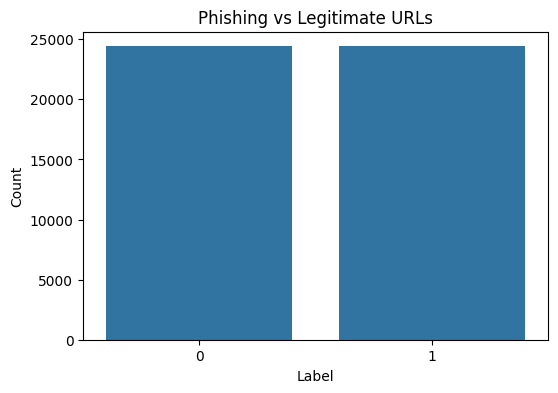

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=url_df
)

plt.title("Phishing vs Legitimate URLs")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

# Visualization 1: Label Distribution graph

Label 0 ~= 24,400 URLs

Label 1 ~= 24,400 URLs

The label distribution analysis shows that the dataset is well-balanced between phishing and legitimate URLs. This is beneficial for machine learning because the model receives approximately equal examples from both classes, reducing bias and improving classification performance

In [29]:
print(url_df['label'].value_counts())

label
0    24407
1    24406
Name: count, dtype: int64


***How is my dataset distributed?***

The dataset contains 48,813 URLs, with 24,407 legitimate URLs and 24,406 phishing URLs. The classes are almost perfectly balanced, which helps prevent model bias during training.

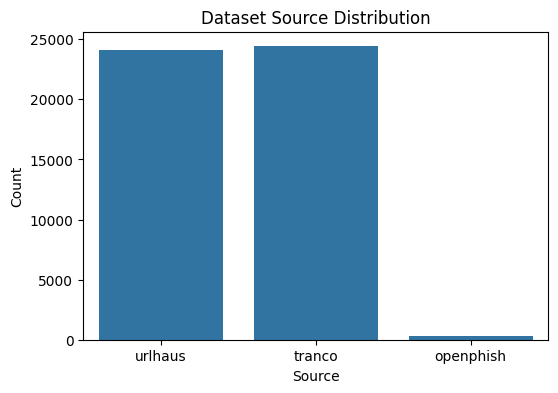

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='source',
    data=url_df
)

plt.title("Dataset Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")

plt.show()

# Visualization 2: Dataset Source Distribution

The URL dataset was created by combining multiple publicly available cybersecurity datasets. Using multiple sources improves dataset diversity and helps the machine learning model learn a wider variety of phishing patterns.

In [31]:
# URL Feature Engineering

url_df["url_length"] = url_df["url"].apply(len)
url_df["dot_count"] = url_df["url"].apply(lambda x: x.count("."))
url_df["hyphen_count"] = url_df["url"].apply(lambda x: x.count("-"))
url_df["slash_count"] = url_df["url"].apply(lambda x: x.count("/"))
url_df["digit_count"] = url_df["url"].apply(
    lambda x: sum(c.isdigit() for c in x)
)
url_df["https"] = url_df["url"].apply(
    lambda x: 1 if x.startswith("https") else 0
)
url_df.head()

# features created are:
# url_length
# dot_count
# hyphen_count
# slash_count
# digit_count
# https

,url,label,source,url_length,dot_count,hyphen_count,slash_count,digit_count,https
0,http://110.37.26.193:54956/bin.sh,1,urlhaus,33,4,0,3,15,0
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus,40,2,0,3,4,1
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus,36,2,1,3,3,1
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus,91,4,0,4,46,0
4,https://bronze.systems,0,tranco,22,1,0,2,0,1


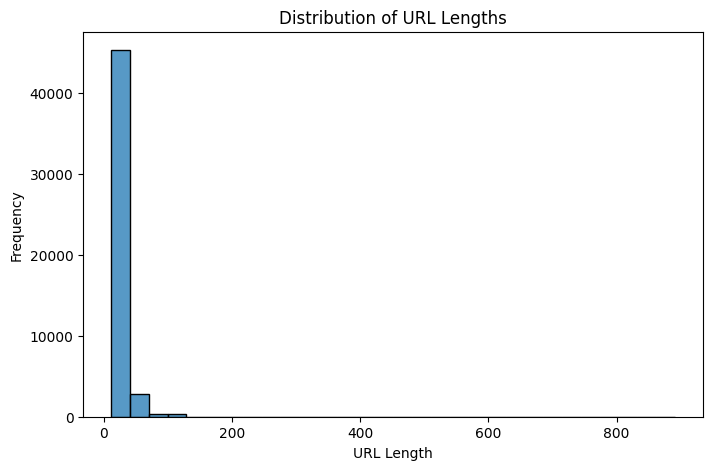

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    url_df['url_length'],
    bins=30
)

plt.title("Distribution of URL Lengths")
plt.xlabel("URL Length")
plt.ylabel("Frequency")

plt.show()

# Visualization 3: URL Length Distribution

The URL length distribution shows that most URLs are relatively short, while a smaller number of URLs are significantly longer. Extremely long URLs are commonly observed in phishing attacks because attackers often append random strings, redirects, or encoded parameters to disguise malicious websites.

In [33]:
print("Average URL Length:", url_df["url_length"].mean())
print("Maximum URL Length:", url_df["url_length"].max())

Average URL Length: 28.076598447134984
Maximum URL Length: 891


Most URLs in the dataset have lengths between 20 and 33 characters. However, some URLs are extremely long, with the maximum observed length being 891 characters. Such unusually long URLs are often associated with phishing attempts because attackers frequently append random strings, redirects, or encoded parameters to hide malicious intentions.

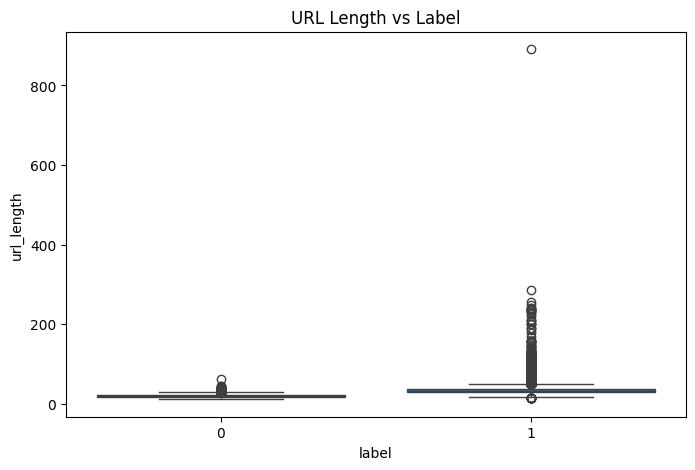

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='url_length',
    data=url_df
)

plt.title("URL Length vs Label")
plt.show()

# shows which features differ between phishing and legitimate URLs.
# phishing URLs are longer

-> Legitimate URLs are usually shorter and more consistent.

-> Phishing URLs tend to have many extreme-length outliers.

In [37]:
X = url_df[[
    "url_length",
    "dot_count",
    "hyphen_count",
    "slash_count",
    "digit_count",
    "https"
]]

y = url_df["label"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (39050, 6)
Testing Samples  : (9763, 6)


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [41]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(y_pred[:10])

[0 1 0 1 1 0 0 1 1 1]


In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

# Accuracy

Accuracy : 0.9998975724674792


Why is accuracy so high:-

The dataset is balanced and the engineered URL features are highly discriminative. In real-world deployment, performance may be lower, so further testing on unseen QR phishing datasets would be needed.

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4835
           1       1.00      1.00      1.00      4928

    accuracy                           1.00      9763
   macro avg       1.00      1.00      1.00      9763
weighted avg       1.00      1.00      1.00      9763



In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

        Feature  Importance
3   slash_count    0.416273
1     dot_count    0.210081
4   digit_count    0.196122
0    url_length    0.119586
5         https    0.057546
2  hyphen_count    0.000393


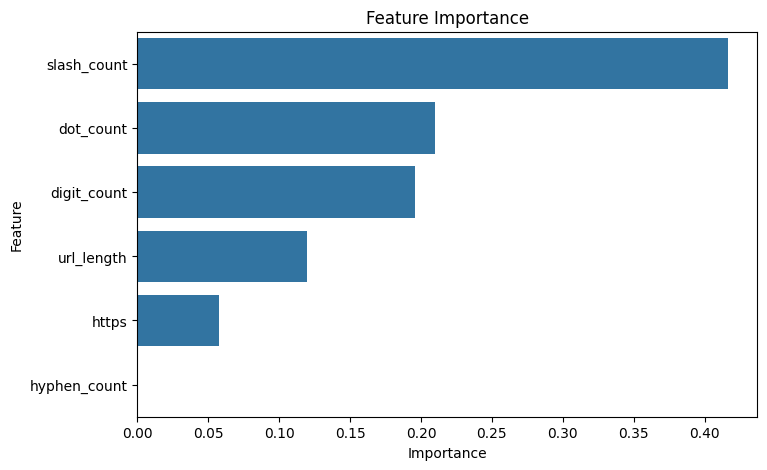

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

In [46]:
!apt-get install -y libzbar0
!pip install pyzbar
# Install QR Decoder

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libzbar0 is already the newest version (0.23.92-4build2).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [49]:
from pyzbar.pyzbar import decode
from PIL import Image
print("QR Decoder Ready!")

from google.colab import files
uploaded = files.upload()
# Upload a QR code image

QR Decoder Ready!


Saving img_0.png to img_0 (1).png


In [50]:
qr_file = list(uploaded.keys())[0]
img = Image.open(qr_file)
decoded_data = decode(img)
if len(decoded_data) > 0:
    extracted_url = decoded_data[0].data.decode("utf-8")
    print("Extracted URL:")
    print(extracted_url)
else:
    print("No QR code detected.")
# Decode QR and Extract URL

Extracted URL:
https://www.southbankmosaics.com


In [51]:
url = extracted_url
url_length = len(url)
dot_count = url.count(".")
hyphen_count = url.count("-")
slash_count = url.count("/")
digit_count = sum(c.isdigit() for c in url)
https = 1 if url.startswith("https") else 0
# Create Features for Prediction

In [52]:
import pandas as pd
new_data = pd.DataFrame({
    "url_length":[url_length],
    "dot_count":[dot_count],
    "hyphen_count":[hyphen_count],
    "slash_count":[slash_count],
    "digit_count":[digit_count],
    "https":[https]
})
new_data
# Create Prediction Data

prediction = rf_model.predict(new_data)
prediction
# Predict

if prediction[0] == 1:
    print("="*50)
    print("⚠️ PHISHING WEBSITE DETECTED")
    print("="*50)
    print("Extracted URL:", extracted_url)
else:
    print("="*50)
    print("✅ SAFE WEBSITE")
    print("="*50)
    print("Extracted URL:", extracted_url)
# Display final result

✅ SAFE WEBSITE
Extracted URL: https://www.southbankmosaics.com


The user uploads a QR code. The system decodes the QR code and extracts the embedded URL. Then the same URL features used during training are generated. These features are passed to the trained Random Forest model, which predicts whether the URL hidden inside the QR code is phishing or legitimate.